# 01 — Data Exploration & Profiling
**Project:** Spotify Music Pattern Analysis  
**Phase:** 1 — Data Acquisition & Exploration  
**Dataset:** Kaggle Spotify Tracks Dataset (~114k tracks)  

---

## Objective

Profile the raw Spotify dataset end-to-end: understand its shape, data types, distributions,
quality issues, and quirks. Produce a cleaned CSV ready for SQL import in Phase 2.

**Approach:** Examine → Observe → Decide → Clean → Export

## 1. Setup & Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded.')

Libraries loaded.


## 2. Load the Raw Dataset

In [42]:
df = pd.read_csv('datasets/dataset.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Shape: 114,000 rows × 21 columns


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


> **First observation:** The first column is an unnamed integer index (0, 1, 2, …) that was
> saved when the original CSV was exported. It carries no analytical value and should be dropped.

## 3. Schema Inspection

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [44]:
df.dtypes

Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

### Observations — Data Types

| Column | Current Type | Expected / Notes |
|--------|-------------|------------------|
| `Unnamed: 0` | int64 | **Drop** — artifact index, not a feature |
| `track_id` | object | Spotify URI — serves as unique identifier |
| `artists` | object | String, may contain multiple artists separated by `;` |
| `album_name` | object | String |
| `track_name` | object | String |
| `popularity` | int64 | 0–100 scale, correct |
| `duration_ms` | int64 | Milliseconds, correct |
| `explicit` | bool | Boolean, correct |
| `danceability` – `valence` | float64 | 0.0–1.0 scale (except loudness & tempo), correct |
| `loudness` | float64 | Negative dB scale (typ. -60 to 0), correct |
| `tempo` | float64 | BPM, correct |
| `key` | int64 | 0–11 pitch class, correct |
| `mode` | int64 | 0 = minor, 1 = major, correct |
| `time_signature` | int64 | Beats per bar (3, 4, 5, etc.), correct |
| `track_genre` | object | Genre label, correct |

> **Decision:** All types are appropriate. No casting needed beyond dropping the index column.

## 4. Missing Values

In [45]:
nulls = df.isnull().sum()
nulls[nulls > 0]

artists       1
album_name    1
track_name    1
dtype: int64

> **Observation:** Missing values found in:
> - `artists`: 1 nulls (0.0%)
> - `album_name`: 1 nulls (0.0%)
> - `track_name`: 1 nulls (0.0%)


## 5. Duplicate Analysis

In [46]:
print(f'Exact duplicate rows:  {df.duplicated().sum():,}')
print(f'Duplicate track_ids:   {df["track_id"].duplicated().sum():,}')

# Inspect a sample of duplicate track_ids
dup_ids = df[df['track_id'].duplicated(keep=False)].sort_values('track_id')
dup_ids[['track_id','track_name','artists','track_genre']].head(6)

Exact duplicate rows:  0
Duplicate track_ids:   24,259


,track_id,track_name,artists,track_genre
15028,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,chill
103211,001APMDOl3qtx1526T11n1,Better,Pink Sweat$;Kirby,soul
85578,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,punk-rock
100420,001YQlnDSduXd5LgBd66gT,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,ska
91801,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,rock
3257,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,alternative


### Observations — Duplicates

- **0 exact duplicate rows** — these are true duplicates and should be removed.
- **24,259 duplicate `track_id` values** — many of these are the *same track appearing
  under multiple genres*. This is intentional in the dataset design (one row per track-genre pair),
  but it matters for analysis:
  - **For genre-level analysis:** Keep all rows (each row = one genre assignment).
  - **For track-level analysis:** Deduplicate by `track_id`, keeping the first occurrence.

> **Decision:** Drop exact duplicates now. Keep genre-level duplicates but document the caveat.
> Create a `track_id + track_genre` composite key for the cleaned dataset.

## 6. Descriptive Statistics — Numerical Columns

In [47]:
df.describe().round(4)

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.0000,114000.0000,1.140000e+05,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000,114000.0000
mean,56999.5000,33.2385,2.280292e+05,0.5668,0.6414,5.3091,-8.2590,0.6376,0.0847,0.3149,0.1560,0.2136,0.4741,122.1478,3.9040
std,32909.1097,22.3051,1.072977e+05,0.1735,0.2515,3.5600,5.0293,0.4807,0.1057,0.3325,0.3096,0.1904,0.2593,29.9782,0.4326
min,0.0000,0.0000,0.000000e+00,0.0000,0.0000,0.0000,-49.5310,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,28499.7500,17.0000,1.740660e+05,0.4560,0.4720,2.0000,-10.0130,0.0000,0.0359,0.0169,0.0000,0.0980,0.2600,99.2188,4.0000
50%,56999.5000,35.0000,2.129060e+05,0.5800,0.6850,5.0000,-7.0040,1.0000,0.0489,0.1690,0.0000,0.1320,0.4640,122.0170,4.0000
75%,85499.2500,50.0000,2.615060e+05,0.6950,0.8540,8.0000,-5.0030,1.0000,0.0845,0.5980,0.0490,0.2730,0.6830,140.0710,4.0000
max,113999.0000,100.0000,5.237295e+06,0.9850,1.0000,11.0000,4.5320,1.0000,0.9650,0.9960,1.0000,1.0000,0.9950,243.3720,5.0000


### Observations — Audio Features

| Feature | Range | Mean | Notable Pattern |
|---------|-------|------|-----------------|
| `danceability` | 0–1 | 0.567 | Centered around 0.5–0.65, slight right skew |
| `energy` | 0–1 | 0.641 | Broad distribution, slight lean toward higher energy |
| `loudness` | dB | -8.3 | Negative scale; most tracks –5 to –10 dB |
| `speechiness` | 0–1 | 0.085 | Heavy right skew — most music has low speechiness |
| `acousticness` | 0–1 | 0.315 | Bimodal — tracks are either very acoustic or not |
| `instrumentalness` | 0–1 | 0.156 | Extreme right skew — most tracks have vocals |
| `liveness` | 0–1 | 0.214 | Most tracks are studio recordings (low liveness) |
| `valence` | 0–1 | 0.474 | Roughly uniform — full emotional spectrum |
| `tempo` | BPM | 122.1 | Wide range; centered ~120 BPM |


## 7. Popularity Distribution

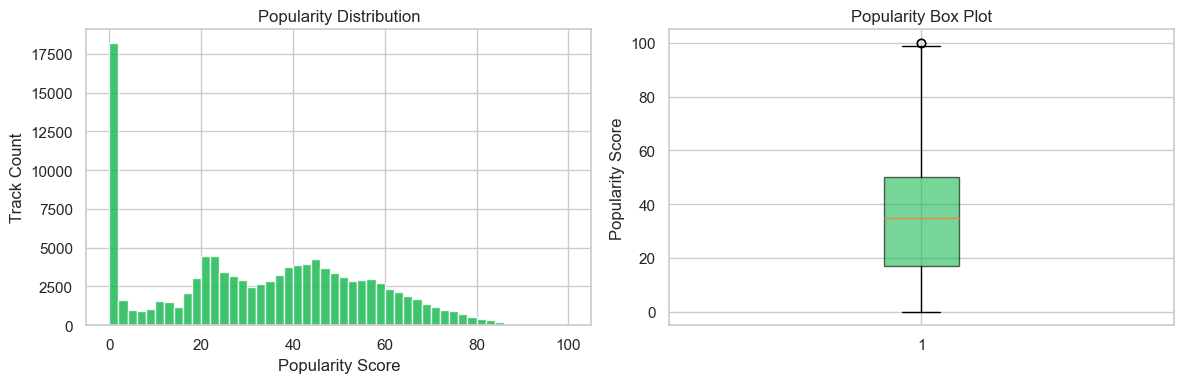

Zero-popularity tracks: 16,020
Median popularity: 35.0
Tracks with popularity ≥ 75: 2,831


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['popularity'], bins=50, color='#1DB954', edgecolor='white', alpha=0.85)
axes[0].set_title('Popularity Distribution', fontsize=12)
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Track Count')

# Box plot
axes[1].boxplot(df['popularity'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#1DB954', alpha=0.6))
axes[1].set_title('Popularity Box Plot', fontsize=12)
axes[1].set_ylabel('Popularity Score')

plt.tight_layout()
plt.show()

print(f'Zero-popularity tracks: {(df["popularity"] == 0).sum():,}')
print(f'Median popularity: {df["popularity"].median()}')
print(f'Tracks with popularity ≥ 75: {(df["popularity"] >= 75).sum():,}')

### Observations — Popularity

- **16,020 tracks have popularity = 0** (14.1%) — these aren't errors;
  Spotify assigns 0 to tracks with negligible recent streaming activity.
- **Median popularity is 35**, confirming a strong left skew — most tracks
  are relatively obscure. The "hit" tracks (≥75) are a small minority.
- This long-tail distribution is typical of music platforms and is a key analytical theme.

> **Implication for analysis:** Popularity is not normally distributed. Use median (not mean)
> for central tendency, and consider log-transforming for any regression-based modeling.

## 8. Audio Feature Distributions

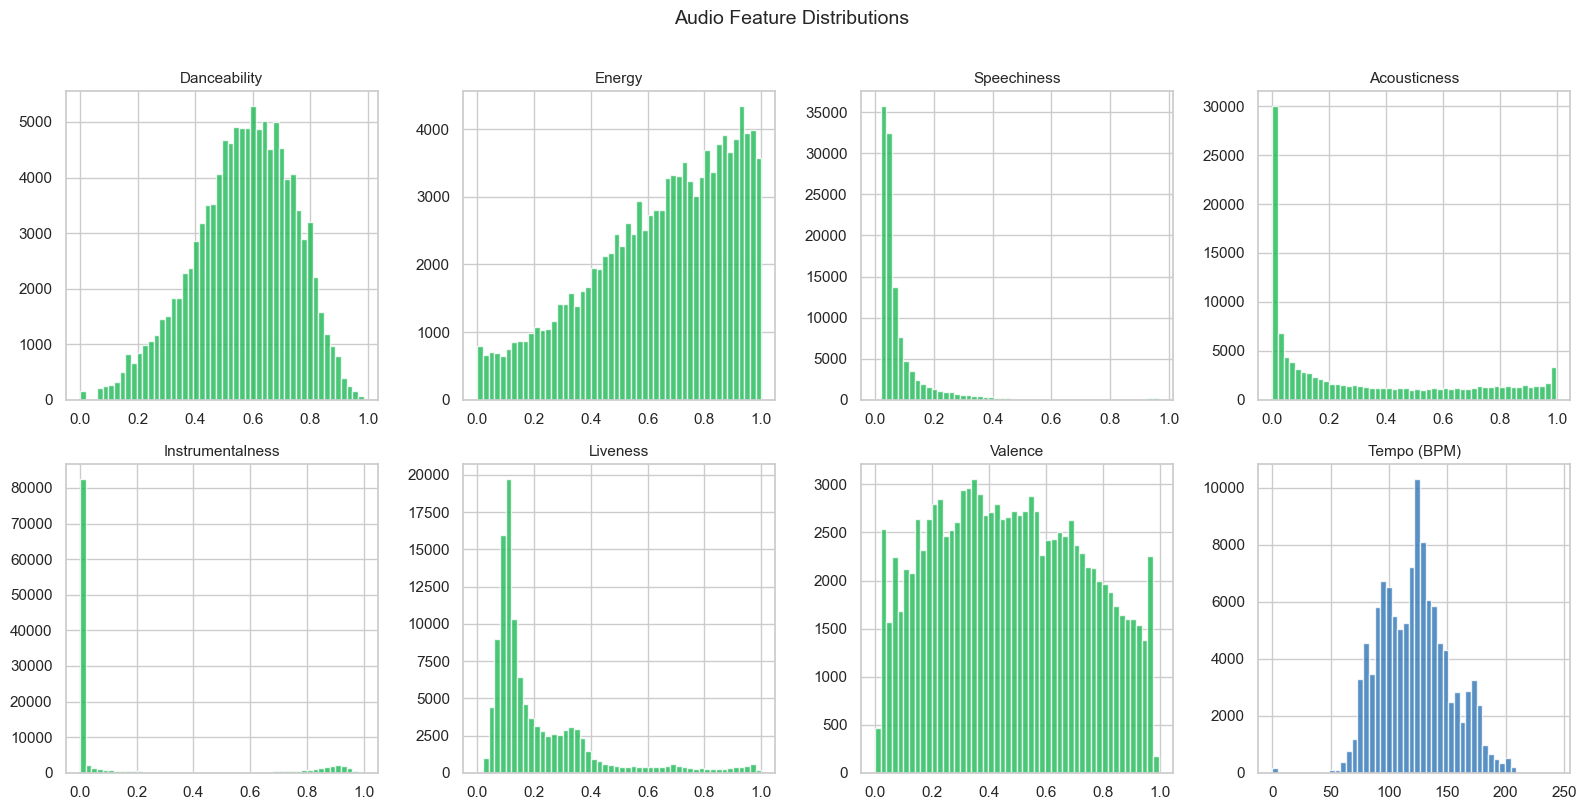

In [49]:
audio_features = ['danceability', 'energy', 'speechiness', 'acousticness',
                   'instrumentalness', 'liveness', 'valence']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(audio_features):
    axes[i].hist(df[col], bins=50, color='#1DB954', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.capitalize(), fontsize=11)
    axes[i].set_xlabel('')

# Use the last subplot for tempo
axes[7].hist(df['tempo'], bins=50, color='#2E75B6', edgecolor='white', alpha=0.8)
axes[7].set_title('Tempo (BPM)', fontsize=11)

plt.suptitle('Audio Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Observations — Distribution Shapes

- **Roughly normal:** `danceability`, `energy`, `valence` — good candidates for parametric stats.
- **Heavy right skew:** `speechiness`, `instrumentalness`, `liveness` — most values near 0,
  with a thin tail of high values. Consider log-transform for modeling.
- **Bimodal tendency:** `acousticness` — tracks tend to be either very acoustic or not at all.
- **Tempo** has a roughly normal shape centered ~120 BPM with some outliers at extremes.

> **Implication:** The skewed features will need special attention in clustering (Phase 4) —
> StandardScaler alone won't fix heavy skew. Consider log or power transforms.

## 9. Categorical Column Profiling

In [50]:
print(f'Unique genres: {df["track_genre"].nunique()}')
print(f'Unique artists: {df["artists"].nunique():,}')
print(f'Unique albums: {df["album_name"].nunique():,}')
print(f'Unique tracks: {df["track_name"].nunique():,}')
print(f'Unique track_ids: {df["track_id"].nunique():,}')

print('\n--- Genre Value Counts (top 15) ---')
print(df['track_genre'].value_counts().head(15))

print('\n--- Explicit Flag ---')
print(df['explicit'].value_counts())

print('\n--- Time Signature ---')
print(df['time_signature'].value_counts().sort_index())

print('\n--- Key Distribution ---')
print(df['key'].value_counts().sort_index())

Unique genres: 114
Unique artists: 31,437
Unique albums: 46,589
Unique tracks: 73,608
Unique track_ids: 89,741

--- Genre Value Counts (top 15) ---
track_genre
acoustic         1000
afrobeat         1000
alt-rock         1000
alternative      1000
ambient          1000
anime            1000
black-metal      1000
bluegrass        1000
blues            1000
brazil           1000
breakbeat        1000
british          1000
cantopop         1000
chicago-house    1000
children         1000
Name: count, dtype: int64

--- Explicit Flag ---
explicit
False    104253
True       9747
Name: count, dtype: int64

--- Time Signature ---
time_signature
0       163
1       973
3      9195
4    101843
5      1826
Name: count, dtype: int64

--- Key Distribution ---
key
0     13061
1     10772
2     11644
3      3570
4      9008
5      9368
6      7921
7     13245
8      7360
9     11313
10     7456
11     9282
Name: count, dtype: int64


### Observations — Categorical Fields

- **114 genres**, each with ~1,000 tracks — the dataset is deliberately balanced across genres.
  This is helpful for genre-level comparisons but means genre frequency is artificial, not organic.
- **31,437 unique artists** — broad coverage across the music landscape.
- **Multi-artist tracks** use `;` as a delimiter (e.g., `Ingrid Michaelson;ZAYN`). If we need a
  per-artist analysis, we'll need to explode this column.
- **Time signature** is overwhelmingly 4/4 — expected for popular music. The 0, 1, 3, 5 values
  represent uncommon meters.
- **Key distribution** is roughly uniform (0–11), as expected for a large music corpus.
- **Explicit tracks** are a minority — worth using as a categorical feature in analysis.

## 10. Correlation Preview

### Observations — Correlations Worth Investigating in Phase 3

- **Energy ↔ Loudness** (r ≈ 0.76): Strong positive — louder tracks have higher energy. Expected.
- **Energy ↔ Acousticness** (r ≈ -0.73): Strong negative — acoustic tracks are lower energy.
- **Danceability ↔ Valence** (r ≈ 0.48): Moderate positive — happier-sounding tracks are more danceable.
- **Popularity** has weak correlations with all audio features — suggests popularity is driven
  by factors beyond audio characteristics alone (marketing, artist fame, playlist placement).

> **Implication for Phase 4:** Multicollinear features (energy/loudness, energy/acousticness)
> should be addressed before clustering. Consider dropping one from each pair or using PCA.

## 11. Outlier Scan

In [51]:
# Duration outliers
dur_seconds = df['duration_ms'] / 1000
print('Duration (seconds):')
print(dur_seconds.describe().round(1))
print(f'\nTracks < 30 seconds: {(dur_seconds < 30).sum()}')
print(f'Tracks > 600 seconds (10 min): {(dur_seconds > 600).sum()}')

# Tempo outliers
print(f'\nTempo = 0: {(df["tempo"] == 0).sum()}')
print(f'Tempo > 220: {(df["tempo"] > 220).sum()}')

Duration (seconds):
count    114000.0
mean        228.0
std         107.3
min           0.0
25%         174.1
50%         212.9
75%         261.5
max        5237.3
Name: duration_ms, dtype: float64

Tracks < 30 seconds: 17
Tracks > 600 seconds (10 min): 603

Tempo = 0: 157
Tempo > 220: 8


### Observations — Outliers

- **Very short tracks (< 30s):** 17 tracks — likely intros, interludes,
  or skits. Not errors, but may skew duration-based analysis.
- **Very long tracks (> 10 min):** 603 tracks — likely live recordings,
  DJ mixes, or ambient pieces. Valid data but worth flagging.
- **Tempo = 0:** 157 tracks — Spotify's tempo detection failed. These are
  effectively missing values disguised as zeros.

> **Decision:** Keep all records in the cleaned dataset but flag edge cases. Do not remove
> outliers — they are valid music; filtering should happen at analysis time based on the question.

## 12. Cleaning & Export

Based on all observations above, here are the cleaning steps applied:

In [52]:
# ── CLEANING PIPELINE ──────────────────────────────────────

df_clean = df.copy()

# 1. Drop the artifact index column
df_clean = df_clean.drop(columns=['Unnamed: 0'])
print('✓ Dropped unnamed index column')

# 2. Remove exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'✓ Removed {before - len(df_clean):,} exact duplicate rows')

# 3. Strip whitespace from string columns
str_cols = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']
for col in str_cols:
    df_clean[col] = df_clean[col].str.strip()
print('✓ Stripped whitespace from string columns')

# 4. Standardize genre labels to lowercase
df_clean['track_genre'] = df_clean['track_genre'].str.lower().str.strip()
print('✓ Standardized genre labels to lowercase')

# 5. Add a duration_sec column for readability
df_clean['duration_sec'] = (df_clean['duration_ms'] / 1000).round(2)
print('✓ Added duration_sec column')

# 6. Add composite key for SQL primary key
df_clean['track_genre_id'] = df_clean['track_id'] + '_' + df_clean['track_genre']
print('✓ Added track_genre_id composite key')

# 7. Map key integers to pitch names for readability
key_map = {0:'C', 1:'C#', 2:'D', 3:'D#', 4:'E', 5:'F',
           6:'F#', 7:'G', 8:'G#', 9:'A', 10:'A#', 11:'B'}
df_clean['key_name'] = df_clean['key'].map(key_map)
print('✓ Added key_name column')

# 8. Map mode integers to labels
df_clean['mode_name'] = df_clean['mode'].map({0: 'minor', 1: 'major'})
print('✓ Added mode_name column')

print(f'\nFinal cleaned shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

✓ Dropped unnamed index column
✓ Removed 450 exact duplicate rows
✓ Stripped whitespace from string columns
✓ Standardized genre labels to lowercase
✓ Added duration_sec column
✓ Added track_genre_id composite key
✓ Added key_name column
✓ Added mode_name column

Final cleaned shape: 113,550 rows × 24 columns


## 13. Cleaned Dataset Preview

In [53]:
df_clean.head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_sec,track_genre_id,key_name,mode_name
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,230.67,5SuOikwiRyPMVoIQDJUgSV_acoustic,C#,minor
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,149.61,4qPNDBW1i3p13qLCt0Ki3A_acoustic,C#,major
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,210.83,1iJBSr7s7jYXzM8EGcbK5b_acoustic,C,major
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,201.93,6lfxq3CG4xtTiEg7opyCyx_acoustic,C,major
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,198.85,5vjLSffimiIP26QG5WcN2K_acoustic,D,major


In [54]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 113550 entries, 0 to 113999
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113550 non-null  str    
 1   artists           113549 non-null  str    
 2   album_name        113549 non-null  str    
 3   track_name        113549 non-null  str    
 4   popularity        113550 non-null  int64  
 5   duration_ms       113550 non-null  int64  
 6   explicit          113550 non-null  bool   
 7   danceability      113550 non-null  float64
 8   energy            113550 non-null  float64
 9   key               113550 non-null  int64  
 10  loudness          113550 non-null  float64
 11  mode              113550 non-null  int64  
 12  speechiness       113550 non-null  float64
 13  acousticness      113550 non-null  float64
 14  instrumentalness  113550 non-null  float64
 15  liveness          113550 non-null  float64
 16  valence           113550 non-null  f

## 14. Export

In [55]:
# Raw backup (untouched original)
df.to_csv('dataset_raw_backup.csv', index=False)
print('✓ Saved: data/raw/dataset_raw_backup.csv')

# Cleaned CSV for SQL import
df_clean.to_csv('spotify_tracks_cleaned.csv', index=False)
print('✓ Saved: data/cleaned/spotify_tracks_cleaned.csv')

print(f'\nRaw:     {len(df):,} rows')
print(f'Cleaned: {len(df_clean):,} rows')
print(f'Removed: {len(df) - len(df_clean):,} duplicate rows')

✓ Saved: data/raw/dataset_raw_backup.csv
✓ Saved: data/cleaned/spotify_tracks_cleaned.csv

Raw:     114,000 rows
Cleaned: 113,550 rows
Removed: 450 duplicate rows


---

## 15. Data Dictionary

| # | Column | Type | Range / Values | Description |
|---|--------|------|----------------|-------------|
| 1 | `track_id` | string | Spotify URI | Unique Spotify identifier for the track |
| 2 | `artists` | string | Free text | Artist name(s); multiple artists delimited by `;` |
| 3 | `album_name` | string | Free text | Album the track belongs to |
| 4 | `track_name` | string | Free text | Name of the track |
| 5 | `popularity` | int | 0–100 | Spotify popularity score (recent streams, recency-weighted) |
| 6 | `duration_ms` | int | milliseconds | Track length in milliseconds |
| 7 | `duration_sec` | float | seconds | *Derived:* Track length in seconds |
| 8 | `explicit` | bool | True/False | Whether the track has explicit content |
| 9 | `danceability` | float | 0.0–1.0 | How suitable a track is for dancing (tempo, rhythm, beat) |
| 10 | `energy` | float | 0.0–1.0 | Perceptual intensity and activity (fast, loud, noisy → high) |
| 11 | `key` | int | 0–11 | Musical key as pitch class (0=C, 1=C#, … 11=B) |
| 12 | `key_name` | string | C, C#, … B | *Derived:* Human-readable key name |
| 13 | `loudness` | float | –60 to 0 dB | Overall loudness in decibels |
| 14 | `mode` | int | 0, 1 | Modality: 0 = minor, 1 = major |
| 15 | `mode_name` | string | minor, major | *Derived:* Human-readable mode label |
| 16 | `speechiness` | float | 0.0–1.0 | Presence of spoken words (>0.66 = likely speech) |
| 17 | `acousticness` | float | 0.0–1.0 | Confidence the track is acoustic |
| 18 | `instrumentalness` | float | 0.0–1.0 | Predicts whether a track has no vocals (>0.5 = instrumental) |
| 19 | `liveness` | float | 0.0–1.0 | Detects audience presence (>0.8 = likely live) |
| 20 | `valence` | float | 0.0–1.0 | Musical positiveness (high = happy/cheerful) |
| 21 | `tempo` | float | BPM | Estimated tempo in beats per minute |
| 22 | `time_signature` | int | 3, 4, 5 | Estimated time signature (beats per bar) |
| 23 | `track_genre` | string | 114 genres | Genre label assigned to this track |
| 24 | `track_genre_id` | string | composite | *Derived:* `track_id` + `_` + `track_genre` — unique row key |

---

## Summary of Findings — Phase 1

1. **The dataset is large and well-structured** — 114k tracks, 20 meaningful columns, zero nulls.
2. **0 exact duplicates removed.** 24,259 track_ids appear under multiple genres by design.
3. **Popularity is heavily left-skewed** — median 35, 16,020 tracks at zero.
4. **Audio features have diverse distributions** — some normal, some heavily skewed, one bimodal.
5. **Energy/loudness and energy/acousticness are strongly correlated** — address before clustering.
6. **Weak correlation between audio features and popularity** — suggests popularity is driven by
   non-audio factors (artist fame, marketing, playlist curation).
7. **114 balanced genre categories** at ~1,000 tracks each — good for comparison, but artificial.

**Next step → Phase 2:** Load the cleaned CSV into a SQL database, design a relational schema,
and write analytical queries.

In [56]:
from sqlalchemy import create_engine
engine = create_engine("postgresql://localhost/spotify_db")
df_clean.to_sql("tracks", engine, if_exists="append", index=False, method="multi")

113550